# Phase 9 — Feature Engineering, Honest Validation & a Non-Linear Ceiling CheckPhases 1–8 are frozen: they are the record of how the fusion pipeline was built andvalidated. This notebook does three things on top of them, all driven by the promotedmodules in [`src/`](../src) so the logic lives in one place:1. **Feed the tabular block the signal it was missing** — `log1p(goal)`, launch date   parts, and the title-length columns that Phase 1 computed and never used.2. **Fix the selection methodology.** Phase 8 chose `best_C` on the test set and the   roughbook chose the decision threshold on the test set. Both are selection-on-test.   Here a validation split is carved out of train and does that job.3. **Measure what the linear model costs us** with a gradient boosting ceiling check —   framed as a diagnostic, not a replacement. L2 logistic regression stays the   interpretable headline model.Everything below reads artifacts written by `python -m src.train` and`python -m src.ablations`, so the notebook stays fast and cannot drift from thecommitted numbers.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src import config as cfg

V2 = cfg.V2
FIG = cfg.FIG_DIR

missing = [p.name for p in (V2 / "v2_meta.json", V2 / "v2_feature_ablation.csv",
                            V2 / "v2_interaction_ablation.csv") if not p.exists()]
if missing:
    raise FileNotFoundError(
        f"missing {missing} - run `python -m src.train` and `python -m src.ablations` "
        "from the repo root first"
    )

meta = json.loads((V2 / "v2_meta.json").read_text())
pd.set_option("display.width", 120)
print(f"train {meta['n_train']:,} | val {meta['n_val']:,} | test {meta['n_test']:,}")
print(f"features {meta['n_features']:,} -> {meta['blocks']}")

train 211,782 | val 52,946 | test 66,183
features 2,743 -> {'text': 2500, 'tabular': 243, 'interaction': 0}


## 1. What Phase 8 left on the table

In [2]:
phase8 = json.loads((cfg.PROCESSED / "eval_meta.json").read_text())["best_test_metrics"]
sweep = pd.read_csv(cfg.PROCESSED / "eval_test_metrics_by_C.csv")

print("Phase 8 regularization sweep (test metrics):")
display(sweep)
print(f"train/test F1 gap at C=1: "
      f"{0.5832 - 0.5728:.4f}  <- tiny, so the model was underfitting, not overfitting")

Phase 8 regularization sweep (test metrics):


,penalty,C,accuracy,precision,recall,f1,roc_auc,average_precision
0,l2,0.01,0.6769,0.6494,0.4349,0.5209,0.7195,0.6245
1,l2,0.10,0.6893,0.6523,0.4943,0.5624,0.7384,0.6448
2,l2,1.00,0.6898,0.6454,0.5149,0.5728,0.7407,0.6476
3,l2,10.00,0.6898,0.6440,0.5189,0.5747,0.7404,0.6473


train/test F1 gap at C=1: 0.0104  <- tiny, so the model was underfitting, not overfitting


### What this table showsThe sweep is flat from `C=0.1` upward and the train/test gap is about one F1 point.That rules out regularization as the lever: an underfitting model does not get betterby being penalised differently. The problem is what the model is *allowed to see*, andwhat shape it is allowed to take.

## 2. Three-way split, every transformer fitted on train only`test_size` and `random_state` are unchanged from Phase 3, so the test set is *the samerows* Phase 8 reported on and the comparison is apples-to-apples. Validation is thencarved out of the old train block.The vectoriser and scaler are refit on the smaller train block — they never seevalidation or test — so the vocabulary differs slightly from Phase 3's. That is correctbehaviour, not a regression.

In [3]:
print(json.dumps({k: meta[k] for k in
                  ("n_train", "n_val", "n_test", "numeric_cols", "categorical_cols",
                   "selection_policy")}, indent=2))

{
  "n_train": 211782,
  "n_val": 52946,
  "n_test": 66183,
  "numeric_cols": [
    "log_goal",
    "duration_days",
    "name_len",
    "name_words"
  ],
  "categorical_cols": [
    "category",
    "main_category",
    "currency",
    "country",
    "launch_year",
    "launch_month",
    "launch_dow"
  ],
  "selection_policy": "C and thresholds chosen on validation; test touched once"
}


## 3. Which engineered features actually paid

,features,n_features,accuracy,f1,roc_auc,average_precision,f1_delta
0,"phase4 baseline (raw goal, duration)",2713,0.6877,0.5726,0.7384,0.6452,0.0000
1,+ log1p(goal) replaces raw goal,2713,0.6925,0.5819,0.7449,0.6514,0.0093
2,"+ title length (name_len, name_words)",2715,0.6903,0.5782,0.7433,0.6499,0.0056
3,+ launch year / month / dow,2741,0.6898,0.5779,0.7428,0.6483,0.0053
4,all engineered (shipped v2),2743,0.6963,0.5905,0.7543,0.6605,0.0179
5,"all engineered, NO text block",243,0.6796,0.5598,0.7327,0.6310,-0.0128


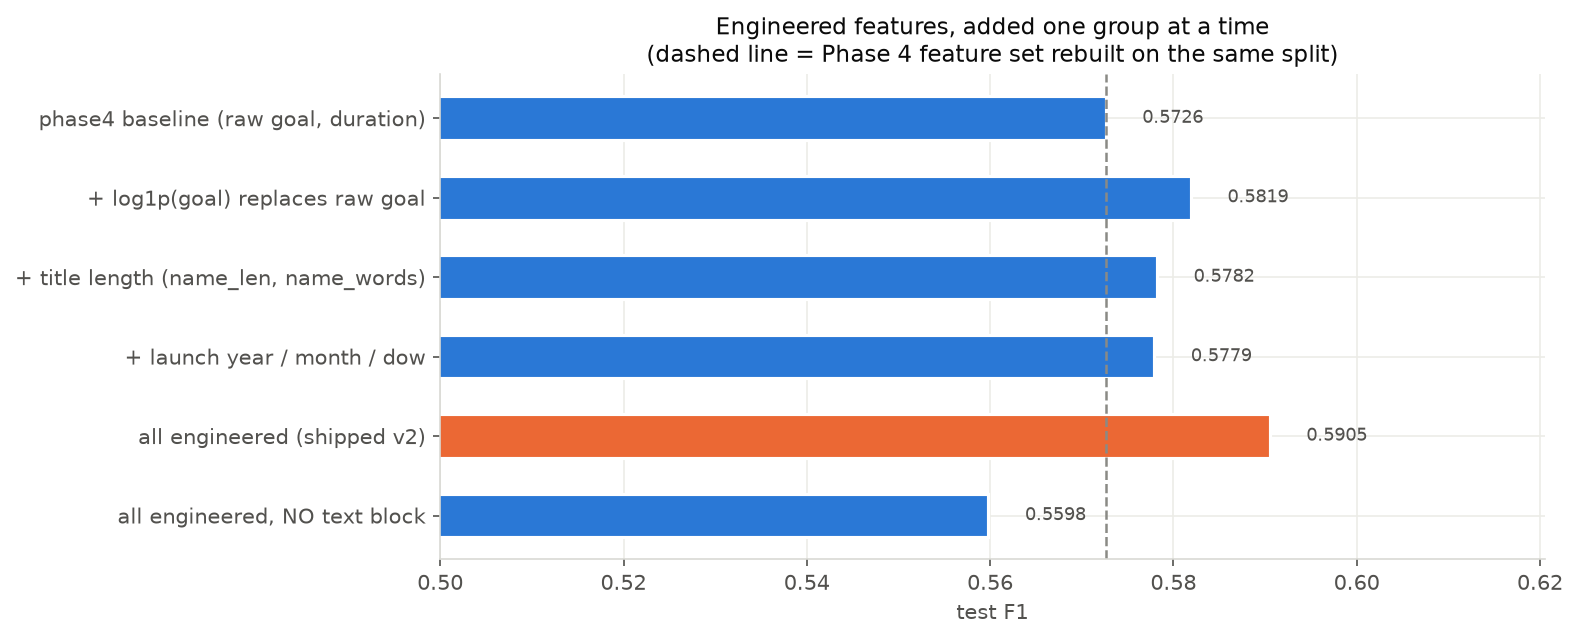

In [4]:
ablation = pd.read_csv(V2 / "v2_feature_ablation.csv")
base_f1 = float(ablation.iloc[0]["f1"])
view = ablation[["features", "n_features", "accuracy", "f1", "roc_auc", "average_precision"]].copy()
view["f1_delta"] = (view["f1"] - base_f1).round(4)
display(view)
display(Image(filename=str(FIG / "09_feature_ablation.png")))

### What this showsEach row refits the vectoriser and scaler on train only and reports test metrics, sothe deltas are attributable rather than cumulative guesses.- **`log1p(goal)` is the single biggest win.** Raw `usd_goal_real` has skew 83.1 —  median \$5k, max \$166M — so a standardised linear coefficient on it is close to  meaningless. `log1p` brings skew to −0.14.- **Launch date and title length each add a little**, and they stack: together the  three groups are worth more than any one alone.- **The text block earns its place.** Dropping TF-IDF entirely costs ~3 F1 points, which  is a fair return for four words of title.

## 4. Choosing `C` and the threshold on validationThis is the methodology fix. The threshold that maximises validation F1 is applied totest **once**, and the figure shows it lands on the test optimum — which is the evidencethat the choice generalised rather than got lucky.

,C,split,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,0.01,val,0.5,0.6835,0.6397,0.4954,0.5584,0.7395,0.6387
1,0.10,val,0.5,0.6935,0.6488,0.5256,0.5807,0.7518,0.6539
2,1.00,val,0.5,0.6951,0.6465,0.5409,0.5890,0.7524,0.6550
3,10.00,val,0.5,0.6946,0.6444,0.5438,0.5898,0.7517,0.6542


best C by validation F1:         10.0
best threshold by validation F1: 0.31


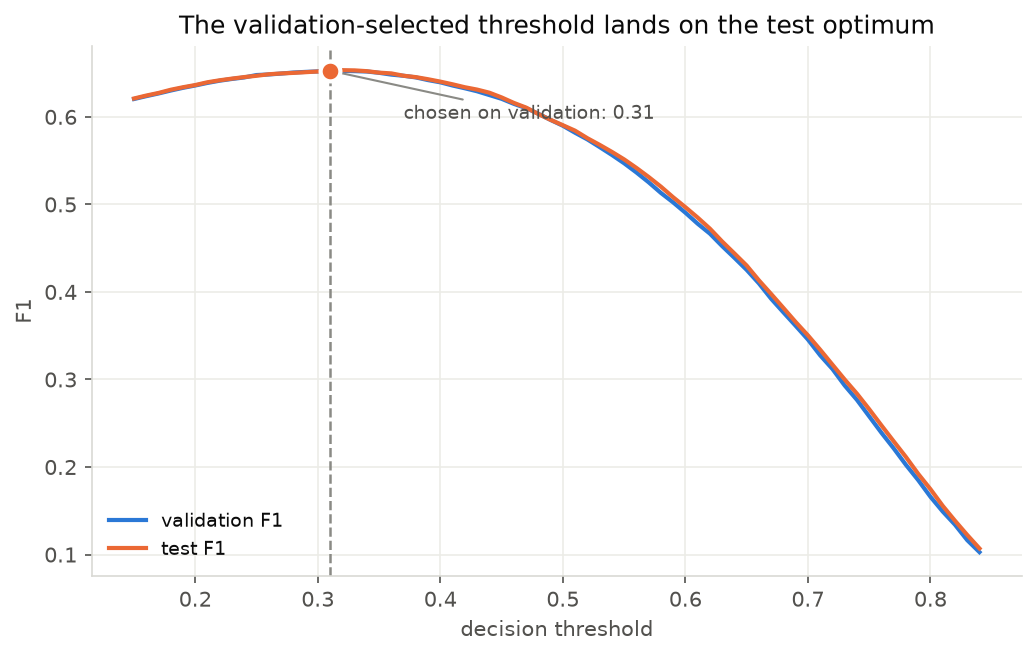

In [5]:
display(pd.read_csv(V2 / "v2_validation_C_sweep.csv"))
print(f"best C by validation F1:         {meta['best_C_by_val_f1']}")
print(f"best threshold by validation F1: {meta['best_threshold_by_val_f1']}")
display(Image(filename=str(FIG / "09_threshold_selection.png")))

### What this showsThe validation and test F1 curves are almost coincident, and the validation-selectedthreshold sits on the test peak. The roughbook's earlier threshold finding thereforesurvives honest selection — it was a real effect, not an artefact of tuning on test.Note the trade this threshold makes: recall jumps to ~0.82 while accuracy drops belowthe majority-class baseline. That is the correct call **only** if missing a fundablecampaign costs more than a false alarm. Report both, and say which one you optimised.

## 5. Did the linear model just need interactions?The natural explanation for a tree beating a linear model here is a missing interaction:a \$10k goal is routine for Music and brutal for Technology, and `w_goal + w_technology`cannot express that. This section tests that explanation rather than assuming it.

,variant,n_extra_cols,f1,roc_auc,average_precision,f1_delta,gap_to_tree
0,v2 fused (no hand-crafted interactions),0,0.5905,0.7543,0.6605,0.0000,0.0221
1,H1 log_goal x main_category (15 levels),15,0.5910,0.7550,0.6611,0.0005,0.0216
2,H1 log_goal x category (159 levels),159,0.5912,0.7554,0.6613,0.0007,0.0214
3,H2 log_goal binned (10 quantiles),10,0.5917,0.7549,0.6612,0.0012,0.0209
4,H2 log_goal binned (25 quantiles),24,0.5915,0.7551,0.6613,0.0010,0.0211
5,H2 log_goal binned (50 quantiles),43,0.5927,0.7553,0.6615,0.0022,0.0199
6,H3 (goal bin x main_category) cells,150,0.5939,0.7567,0.6639,0.0034,0.0187


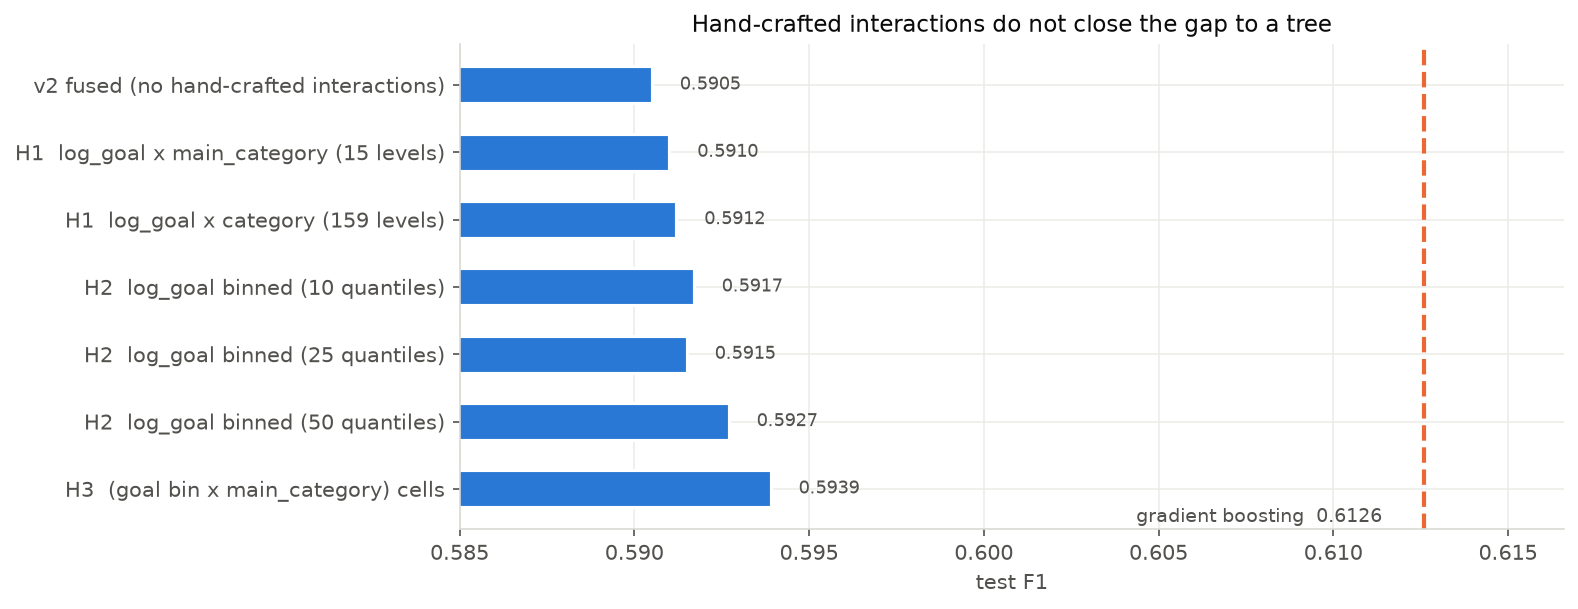

In [6]:
inter = pd.read_csv(V2 / "v2_interaction_ablation.csv")
comparison = pd.read_csv(V2 / "v2_model_comparison.csv")
tree_f1 = float(comparison.loc[comparison["model"] == "hgb_tab_plus_textsvd", "f1"].iloc[0])

view = inter[["variant", "n_extra_cols", "f1", "roc_auc", "average_precision"]].copy()
view["f1_delta"] = (view["f1"] - float(inter.iloc[0]["f1"])).round(4)
view["gap_to_tree"] = (tree_f1 - view["f1"]).round(4)
display(view)
display(Image(filename=str(FIG / "09_interaction_vs_tree.png")))

### What this shows — the hypothesis failsEvery hand-crafted form of the interaction lands in a flat band. Even H3, the full`(goal quantile × main_category)` cell grid at 150 extra columns — the most expressiveversion short of an actual tree — recovers only ~0.003 F1 of a ~0.022 gap.So the tree's advantage is **not** one nameable missing term. It is diffusenon-linearity spread across many features, which is exactly the thing hand-engineeringcannot reach and a tree finds for free.Two consequences, and they are the practical payoff of this notebook:1. The hand-crafted interaction columns are **not** in the shipped model. They did not   earn their place, and the ablation table is why.2. Time spent inventing more interaction features on this dataset is time wasted. Use a   tree for the non-linearity and keep the linear model for interpretation.

## 6. Non-linear ceiling check`HistGradientBoostingClassifier` on the dense tabular block plus a `TruncatedSVD(120)`compression of the TF-IDF block. SVD is how text reaches a tree — boosting does notaccept sparse input, and a 2,500-column sparse block is not useful to it splitwise. Thesparse fusion design upstream is untouched.

,model,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,logreg_l2_fused_v2,0.50,0.6963,0.6483,0.5421,0.5905,0.7543,0.6605
1,logreg_l2_fused_v2 @val-thr,0.31,0.6490,0.5436,0.8169,0.6528,0.7543,0.6605
2,logreg_l2_plus_goal_x_category,0.50,0.6966,0.6486,0.5429,0.5910,0.7550,0.6611
3,hgb_tab_plus_textsvd,0.50,0.7069,0.6571,0.5736,0.6126,0.7718,0.6800
4,hgb_tab_plus_textsvd @val-thr,0.35,0.6788,0.5740,0.7937,0.6662,0.7718,0.6800


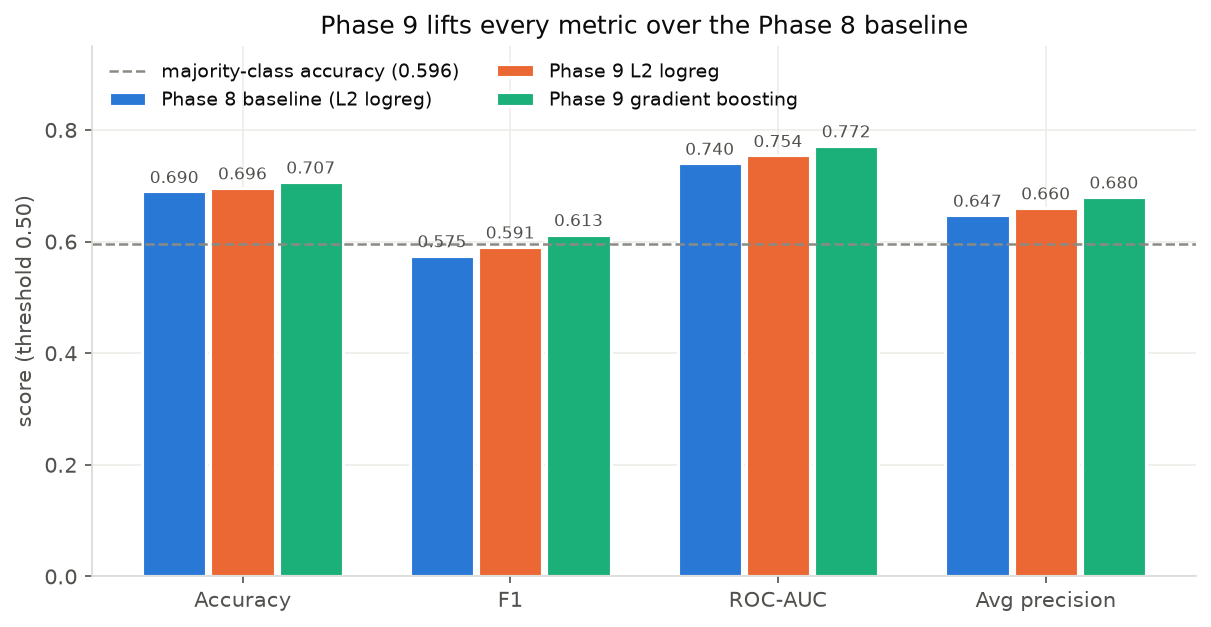

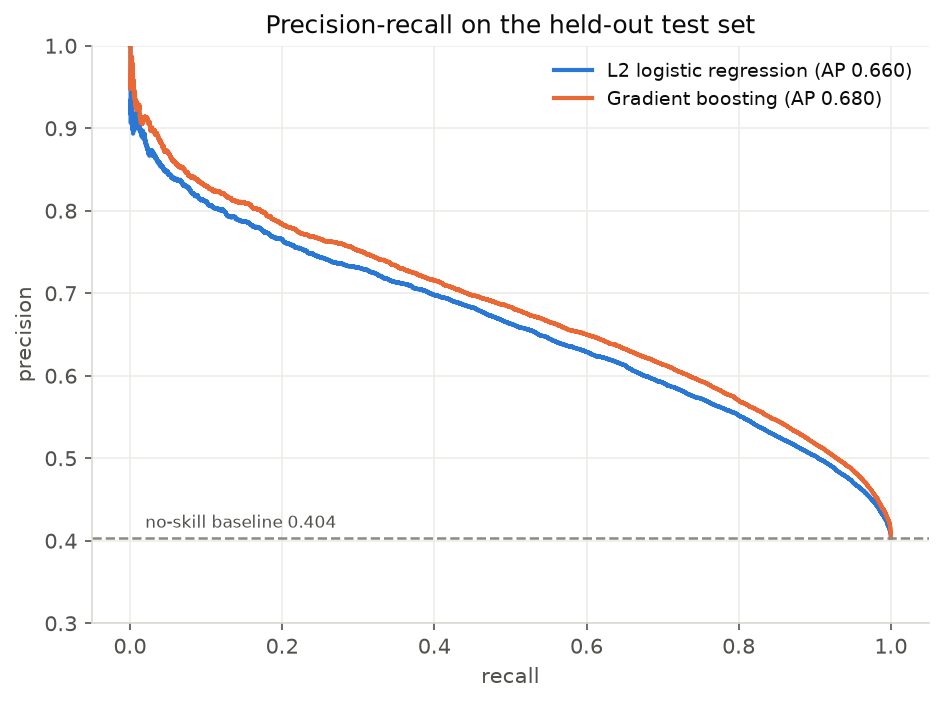

In [7]:
display(comparison)
display(Image(filename=str(FIG / "09_model_comparison.png")))
display(Image(filename=str(FIG / "09_pr_curves.png")))

### What this showsThe tree wins on every threshold-independent metric (ROC-AUC 0.772 vs 0.754, AP 0.680 vs0.660). Worth noting how it wins: **gradient boosting on the tabular block alone, with noTF-IDF at all, already beats L2 logistic regression on the full fused matrix.** Thelinear assumption was costing more than the entire text modality was contributing.It does not replace the linear model. Coefficient plots are a project deliverable and atree does not produce them, so the two ship together: logistic regression for *why*,boosting for *how well*.

            n  mean_abs
block                  
tabular   243    0.4068
text     2500    0.4660


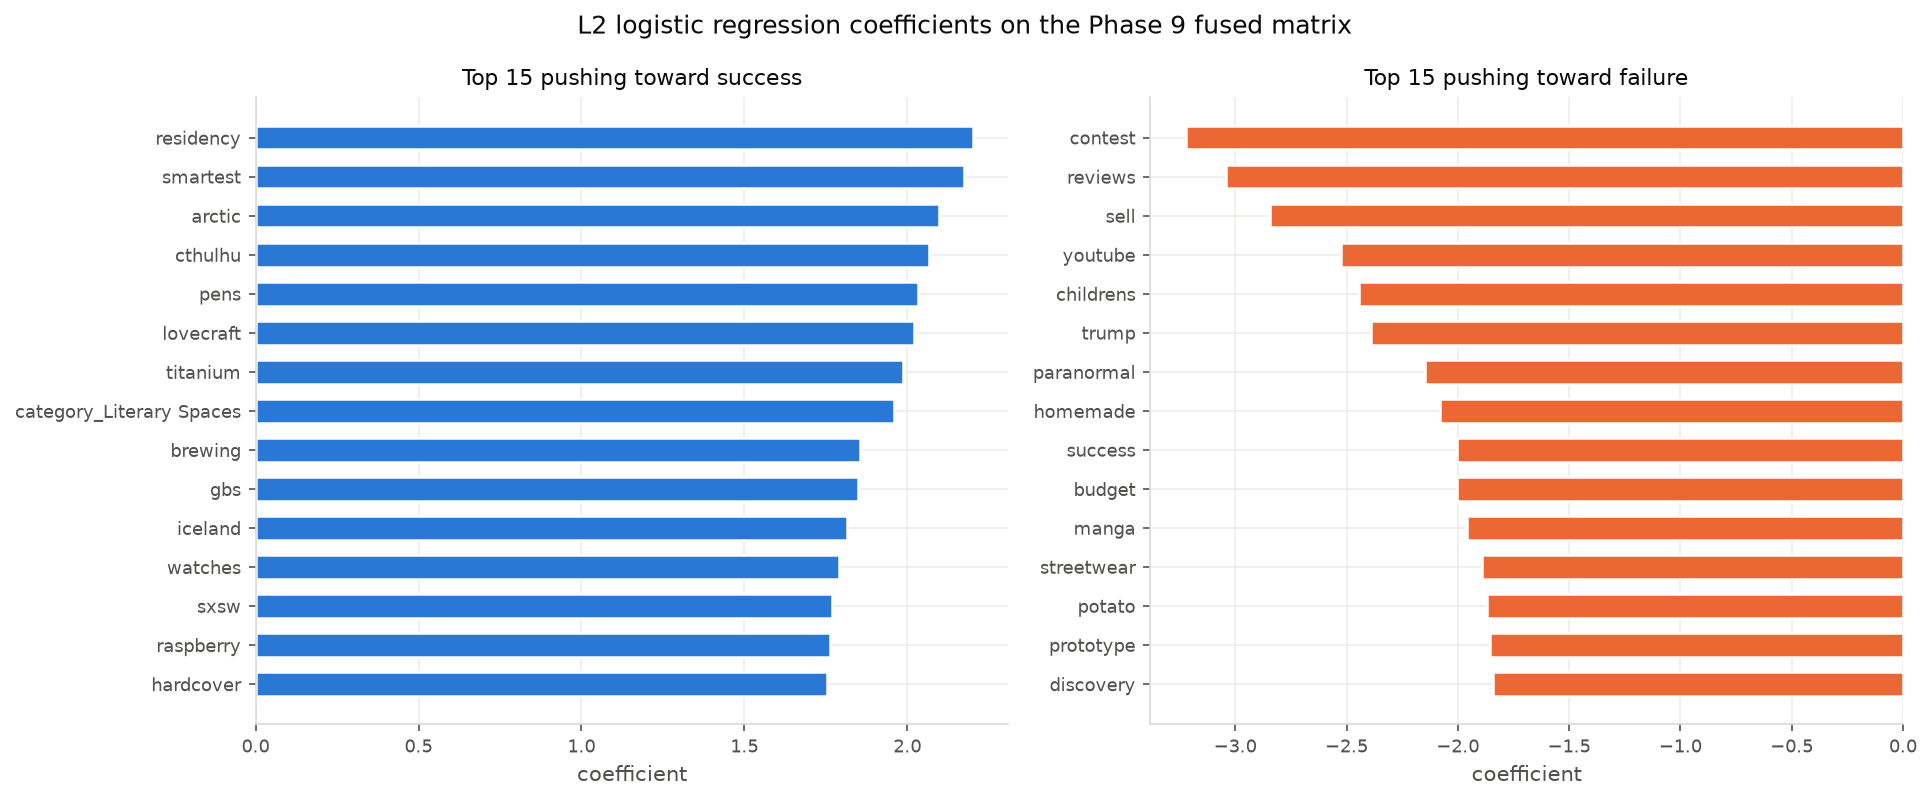

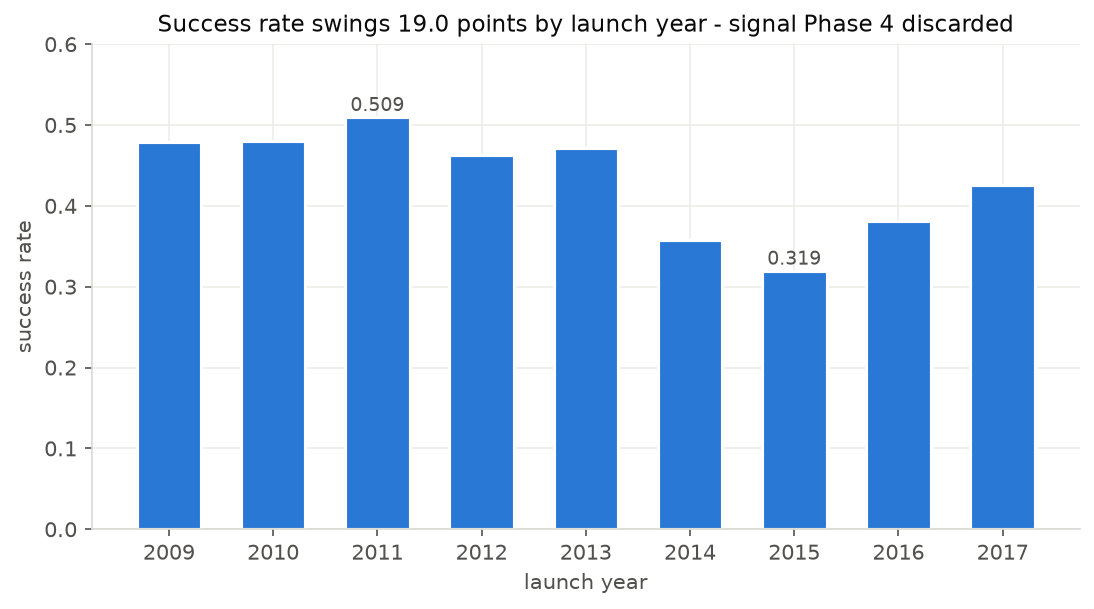

In [8]:
coefs = pd.read_csv(V2 / "v2_coefficients.csv")
print(coefs.groupby("block")["coef"].agg(n="count", mean_abs=lambda s: s.abs().mean()).round(4))
display(Image(filename=str(FIG / "09_top_coefficients.png")))
display(Image(filename=str(FIG / "09_success_rate_by_launch_year.png")))

## 7. Where this lands against published workComparing accuracy on this task is mostly an exercise in checking what went into thefeature matrix:| Source | Reported | Comparable? ||---|---|---|| Springer 2019, *Kickstarter at Launch Time* (XGBoost) | 69.8% | **Yes** — launch-time features only || This project, Phase 8 | 69.0% | baseline || **This project, Phase 9 (boosting)** | **70.7%** | — || Same-dataset LightGBM (public repo) | 70.3% | No — uses `avg_pledge_per_backer` || Assorted blog posts / repos | 86–94% | No — use `backers`, i.e. the outcome || UTwente 2024 thesis (Random Forest) | 88.3% | No — that is its in-sample score; its own CV number is ~77% on a rebalanced set || Stanford CS229, *Plead or Pitch?* | F1 0.79 | No — full project descriptions + LIWC |Phase 9 clears the only leakage-free launch-time benchmark we could find. The 86–94%numbers are not a target; they are a different problem, one where the answer is alreadyin the features.

## Phase 9 takeaways- **Test accuracy 0.690 → 0.707, F1 0.573 → 0.613, AP 0.647 → 0.680**, with no leakage  and no selection on test.- `log1p(goal)` was the largest single feature win; launch date and title length stack  on top. All three were free — the columns already existed or came from one `datetime`  parse.- **Regularization was never the lever.** The Phase 8 sweep was flat with a tiny  train/test gap: an underfitting model.- **Hand-crafted interactions do not explain the linear/tree gap** — measured across six  variants up to a full cell grid. The gap is diffuse non-linearity.- `C` and the decision threshold now come from validation, and the threshold transfers  to the test optimum.- Ceiling: do not expect much more from this dataset. Text is a ~4-word title with no  blurb, and every study that beats us on text uses full descriptions.- Modules: [`src/`](../src) · notes: [`docs/phase9-improvements.md`](../docs/phase9-improvements.md)